# 침수흔적도 × 맨홀 노드 공간조인 → GNN 노드 침수 라벨

> 기준: 관악구 · 작성 2026-07-02 · 선행: `flood_trace_crosscheck.ipynb`(사건 검증)

**목적**: 서울시 침수흔적도(ground-truth 폴리곤)를 **GNN 맨홀 노드(13,272)** 에 공간조인해 **노드별 침수 라벨**을 만든다. → 라벨 없어 막혔던 하수 라우팅 GNN에 실제 침수 정답(node label)을 부여.

**입력**:
- 노드: `dataset/processed/eda_based/gnn_manhole_nodes.parquet` (13,272, EPSG:5181)
- 폴리곤: `03_GIS/derived/침수흔적도_2022_관악.gpkg` (관악 2022, EPSG:5179)

**라벨 정의**(2022-08-08 사건일 + 2022 전체 2종):
- `flood_in` = 노드가 침수 폴리곤 **내부**
- `dist_m` = 최근접 침수 폴리곤까지 거리
- `flood_25m`/`flood_50m` = 25m/50m 이내(맨홀-폴리곤 위치오차·표면류 흡수)
- `depth_max` = 겹치는/최근접 폴리곤 침수심(F_SHIM) 최대
- `cause` = 대표 원인(F_RSN_DTL)

In [1]:
import os, sys
while not os.path.exists("scripts/krfont.py") and os.getcwd() != "/":
    os.chdir("..")
sys.path.insert(0, "scripts")
from krfont import set_korean; set_korean()
import pandas as pd, numpy as np, geopandas as gpd
import matplotlib.pyplot as plt

CRS = "EPSG:5181"  # 노드 좌표계(관망 GIS)
print("cwd:", os.getcwd())

cwd: /home/namjun/city_flood


## 1. 노드 · 폴리곤 로드 (동일 좌표계로)

In [2]:
nd = pd.read_parquet("dataset/processed/eda_based/gnn_manhole_nodes.parquet")
nodes = gpd.GeoDataFrame(nd, geometry=gpd.points_from_xy(nd["x"], nd["y"]), crs=CRS)
print(f"GNN 노드 {len(nodes):,} · 관측(센서) {int(nodes['is_observed'].fillna(False).sum())}")

poly = gpd.read_file("03_GIS/derived/침수흔적도_2022_관악.gpkg").to_crs(CRS)
poly = poly[poly.geometry.notna() & ~poly.geometry.is_empty].copy()
poly["F_SHIM"] = pd.to_numeric(poly["F_SHIM"], errors="coerce")
p0808 = poly[poly["day"] == "20220808"].copy()
print(f"폴리곤 2022 전체 {len(poly):,} · 2022-08-08 {len(p0808):,}")

GNN 노드 13,272 · 관측(센서) 13
폴리곤 2022 전체 3,572 · 2022-08-08 2,120


## 2. 공간조인 함수 (내부/거리/침수심/원인)

In [3]:
def label_nodes(polys, tag):
    """노드별: 내부여부·최근접거리·침수심max·대표원인. tag는 컬럼 접미사."""
    # (a) 최근접 폴리곤(거리 + 그 폴리곤 속성)
    near = gpd.sjoin_nearest(nodes[["node_id", "geometry"]], polys[["F_SHIM", "F_RSN_DTL", "geometry"]],
                             how="left", distance_col="dist_m")
    near = near.sort_values("dist_m").drop_duplicates("node_id")  # 노드당 1개
    # (b) 내부 폴리곤들의 침수심 max (겹침 대비)
    inside = gpd.sjoin(nodes[["node_id", "geometry"]], polys[["F_SHIM", "geometry"]], predicate="within", how="inner")
    depth_in = inside.groupby("node_id")["F_SHIM"].max()
    out = pd.DataFrame({"node_id": nodes["node_id"].values})
    out = out.merge(near[["node_id", "dist_m", "F_SHIM", "F_RSN_DTL"]], on="node_id", how="left")
    out[f"flood_in_{tag}"]   = (out["dist_m"] <= 0.01).astype("int8")
    out[f"flood_25m_{tag}"]  = (out["dist_m"] <= 25).astype("int8")
    out[f"flood_50m_{tag}"]  = (out["dist_m"] <= 50).astype("int8")
    out[f"dist_m_{tag}"]     = out["dist_m"].round(1)
    # 침수심: 내부면 내부 max, 아니면 최근접 폴리곤 값
    depth = out["node_id"].map(depth_in)
    out[f"depth_max_{tag}"]  = depth.fillna(out["F_SHIM"]).round(2)
    out[f"cause_{tag}"]      = out["F_RSN_DTL"]
    return out.drop(columns=["dist_m", "F_SHIM", "F_RSN_DTL"])

lab_0808 = label_nodes(p0808, "0808")
lab_2022 = label_nodes(poly,  "2022")
labels = lab_0808.merge(lab_2022, on="node_id")
labels.head()

,node_id,flood_in_0808,flood_25m_0808,flood_50m_0808,dist_m_0808,depth_max_0808,cause_0808,flood_in_2022,flood_25m_2022,flood_50m_2022,dist_m_2022,depth_max_2022,cause_2022
0,0000-000-01,0,1,1,3.8,0.2,침수,0,1,1,3.8,0.2,침수
1,0001-100-00,0,1,1,11.6,0.2,침수,0,1,1,4.4,0.2,침수
2,0001-150-00,0,1,1,16.1,0.2,침수,0,1,1,3.5,0.2,침수
3,0002-100-00,0,1,1,12.5,0.2,침수,0,1,1,6.1,0.2,침수
4,0003-100-00,0,0,0,1461.5,0.2,침수,0,0,0,1461.5,0.2,침수


In [4]:
print("=== 2022-08-08 노드 라벨 ===")
for c in ["flood_in_0808", "flood_25m_0808", "flood_50m_0808"]:
    k = int(labels[c].sum()); print(f"  {c:16s}: {k:5,} 노드 ({k/len(labels)*100:4.1f}%)")
print("=== 2022 전체 노드 라벨 ===")
for c in ["flood_in_2022", "flood_25m_2022", "flood_50m_2022"]:
    k = int(labels[c].sum()); print(f"  {c:16s}: {k:5,} 노드 ({k/len(labels)*100:4.1f}%)")
print("\n내부 노드 침수심(2022-08-08) 요약:")
d = labels.loc[labels["flood_in_0808"] == 1, "depth_max_0808"]
print(d.describe()[["count", "min", "50%", "max", "mean"]].round(2).to_string())

=== 2022-08-08 노드 라벨 ===
  flood_in_0808   : 1,229 노드 ( 9.3%)
  flood_25m_0808  : 4,511 노드 (34.0%)
  flood_50m_0808  : 6,709 노드 (50.6%)
=== 2022 전체 노드 라벨 ===
  flood_in_2022   : 1,276 노드 ( 9.6%)
  flood_25m_2022  : 5,605 노드 (42.2%)
  flood_50m_2022  : 8,563 노드 (64.5%)

내부 노드 침수심(2022-08-08) 요약:
count    1229.00
min         0.20
50%         0.30
max         0.60
mean        0.39


## 3. 관측(센서) 노드의 라벨 — 사건과 일치하는지
센서 스냅 노드가 침수 라벨을 받는지 = 2차 보고서 사건과 그래프 라벨의 정합 확인.

In [5]:
snap = pd.read_parquet("dataset/processed/eda_based/gnn_manhole_sensor_snap.parquet")
obs = snap.merge(labels, on="node_id", how="left")
obs_g = obs[obs["sensor_id"].str.startswith("21-")].sort_values("sensor_id")
cols = ["sensor_id", "node_id", "flood_in_0808", "flood_50m_0808", "depth_max_0808", "cause_0808"]
print(obs_g[cols].to_string(index=False))
ev7 = [f"21-000{i}" for i in range(1, 8)]
hit = obs_g[obs_g["sensor_id"].isin(ev7)]["flood_50m_0808"].sum()
print(f"\n2022-08-08 사건 7센서 중 50m내 침수 라벨: {int(hit)}/7")

sensor_id     node_id  flood_in_0808  flood_50m_0808  depth_max_0808 cause_0808
  21-0001 2022-601-01              1               1             0.6     배수용량초과
  21-0002 4115-650-00              1               1             0.3     배수용량초과
  21-0003  8103-403-1              1               1             0.3     배수용량초과
  21-0004 1009-300-01              1               1             0.3     배수용량초과
  21-0005  6011-705-1              1               1             0.6     배수용량초과
  21-0006  7201-150-1              0               0             0.3     배수용량초과
  21-0007  7548-202-1              0               1             0.3     배수용량초과
  21-0008 4101-201-01              1               1             0.6         침수
  21-0009  7603-100-1              1               1             0.3     배수용량초과
  21-0010  4113-100-1              1               1             0.3     배수용량초과
  21-0011  5039-605-1              0               1             0.2         침수
  21-0012  7539-102-1              0    

## 4. 지도 — 노드 침수 라벨

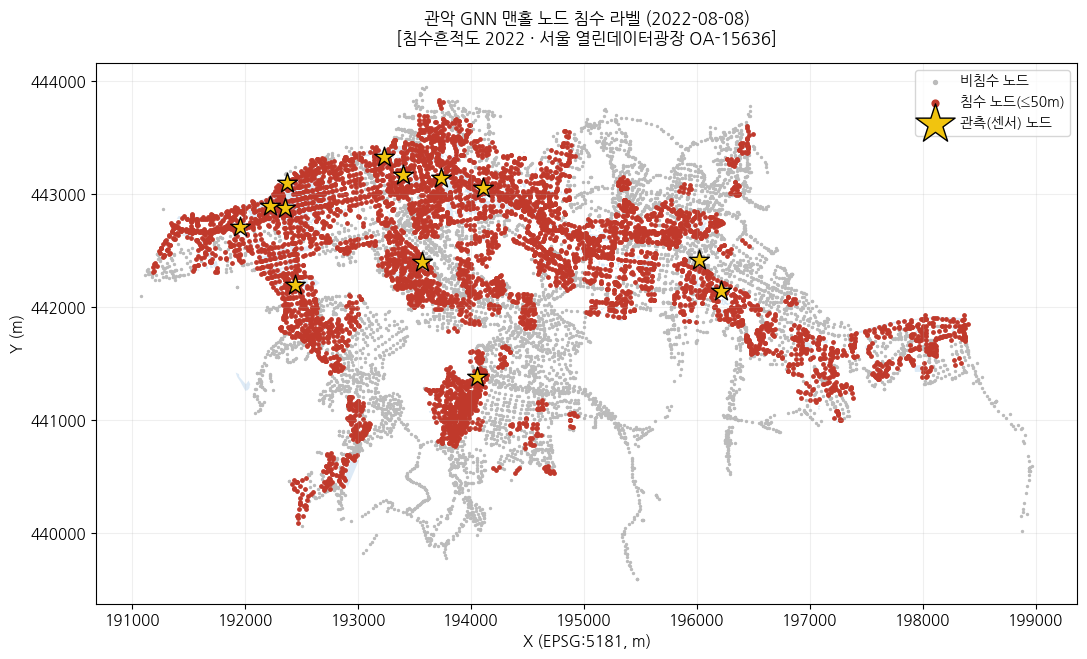

In [6]:
labN = nodes.merge(labels, on="node_id")
fig, ax = plt.subplots(figsize=(11, 10))
p0808.plot(ax=ax, color="#cfe2f3", alpha=0.7, edgecolor="none")
labN[labN["flood_50m_0808"] == 0].plot(ax=ax, color="#bbb", markersize=2, label="비침수 노드")
labN[labN["flood_50m_0808"] == 1].plot(ax=ax, color="#c0392b", markersize=6, label="침수 노드(≤50m)")
obs_pts = labN[labN["is_observed"].fillna(False)]
obs_pts.plot(ax=ax, color="#f1c40f", marker="*", markersize=220, edgecolor="k", label="관측(센서) 노드")
ax.set_title("관악 GNN 맨홀 노드 침수 라벨 (2022-08-08)\n"
             "[침수흔적도 2022 · 서울 열린데이터광장 OA-15636]", fontsize=12, y=1.02)
ax.legend(loc="upper right", fontsize=10, markerscale=2)
ax.set_xlabel("X (EPSG:5181, m)"); ax.set_ylabel("Y (m)"); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("reports/figures_demo/floodtrace_manhole_labels_2022.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. 저장 — 노드 침수 라벨

In [7]:
# node_idx 부착(그래프 순서와 정합)
labels_out = labels.merge(nd[["node_id", "node_idx", "is_observed"]], on="node_id", how="left")
OUT = "dataset/processed/eda_based/gnn_manhole_flood_labels_2022.parquet"
labels_out.to_parquet(OUT, index=False)
print("저장:", OUT, labels_out.shape)
print("컬럼:", list(labels_out.columns))

저장: dataset/processed/eda_based/gnn_manhole_flood_labels_2022.parquet (13272, 15)
컬럼: ['node_id', 'flood_in_0808', 'flood_25m_0808', 'flood_50m_0808', 'dist_m_0808', 'depth_max_0808', 'cause_0808', 'flood_in_2022', 'flood_25m_2022', 'flood_50m_2022', 'dist_m_2022', 'depth_max_2022', 'cause_2022', 'node_idx', 'is_observed']


## 결론
- 침수흔적도 폴리곤을 **GNN 맨홀 노드 13,272개**에 공간조인해 노드별 침수 라벨(내부/25m/50m·침수심·원인) 생성.
- 관측 센서 노드가 사건일(2022-08-08) 침수 라벨을 받는지로 그래프-사건 정합 확인.
- **의의**: 라벨 부재로 막혔던 하수 라우팅 GNN에 **실제 침수 정답(node label)** 확보 → semi-supervised 노드 분류·전파 학습의 정답지.
- **다음**: (a) 다른 연도 흔적도 추가 → 다년 라벨, (b) 사건일 F_SAT_TM과 센서 피크 시각 정합, (c) 이 라벨로 GNN 노드 분류 재학습(레이더 강우 입력과 결합).